**Abby Ortego**

**CMPS 6790 Data Science**

**Milestone 1**

# Imports

In [19]:
import requests
from bs4 import BeautifulSoup
import regex as re
import pandas as pd
import numpy as np

# Motivation

[Magic: The Gathering](https://magic.wizards.com/en/intro) is a popular trading card game with competitive tournaments hosted around the globe. During the tournaments, players create their own decks (possibly inspired by existing ones) and battle one another until one lone victor remains. 

This yields the question: what makes a winning deck? 

The community is divided by this. Some would (naively) say it's the price of the cards in the deck while others would argue properties on the cards hold more sway. This notebook is the first step into answering this question with methods grounded in statistical reasoning. 

# Extracting, Transforming, and Loading the Data

To answer this question, we need access to tournament data from Magic: The Gathering events. If we can collect the decks that were used in the tournaments and how they fared, we can start making informed guesses. 

Thankfully, [MTG Top 8](https://mtgtop8.com/) compiles this data from reliable tournament reporting services (e.g., [Melee](https://melee.gg/), [Magic Events](https://magic.gg/), etc.). This site does not offer an API to collect this data, though, so we will have to scrape their pages for the data we're interested in. The site's [policies](https://mtgtop8.com/privacy) do not ban web scrapers. 

## Getting Tournament Data

MTG Top 8 organizes decks by tournament, so we will first need to compile a list of tournaments and their links on the site. Magic: The Gathering is quite popular, though, with a variety of play formats and tournaments hosted all around the globe, so grabbing data for *all* tournaments on the site is not feasible. 

For this notebook, we will focus only on major tournaments played in the Standard format during the last month. [Explain why you chose this scope].

This [link](https://mtgtop8.com/format?f=ST&meta=46&a=) lists all major tournaments in the last two months in the "Last 20 Events" table. This is close to what we're interested in! 

This table only displays 20 items at a time, though, which means we'll have to loop over the pages and scrape this table for each one.

In [2]:
# get all tournaments tables
tournaments_tables = []
for page in range(1, 7):    # there are roughly 6 pages worth of data
    r = requests.get(f"https://mtgtop8.com/format?f=ST&meta=46&cp={page}")
    if r.status_code != 200:
        print(f"Could not scrape events from page {page}.")
        continue
    #

    soup = BeautifulSoup(r.content)
    tables = soup.find_all("table")     # using soup to grab all tables on the page
    tournaments_tables.append(tables[2])   # the table we're interested in is the third one on the page 
#
display(tournaments_tables)

[<table align="center" border="0" class="Stable" width="98%">
 <tr class="hover_tr">
 <td align="center" width="5%"><img height="14" src="/graph/online/mtgo.png" title="MTG Online"/></td>
 <td class="S14" width="70%"><a href="event?e=80553&amp;f=ST">MTGO Challenge 64</a> <span class="new">NEW</span></td>
 <td align="center" width="13%"><img src="/graph/star.png"/><img src="/graph/star.png"/></td>
 <td align="right" class="S12" width="12%">16/02/26</td>
 </tr>
 <tr class="hover_tr">
 <td align="center" width="5%"><img height="14" src="/graph/online/mtgo.png" title="MTG Online"/></td>
 <td class="S14" width="70%"><a href="event?e=80490&amp;f=ST">MTGO Challenge 32</a> <span class="new">NEW</span></td>
 <td align="center" width="13%"><img src="/graph/star.png"/><img src="/graph/star.png"/></td>
 <td align="right" class="S12" width="12%">15/02/26</td>
 </tr>
 <tr class="hover_tr">
 <td align="center" width="5%"><img height="17" src="/graph/online/paper.png" title="Paper"/></td>
 <td class="

Now that we have the tournament tables, we can extract the information we're interested in from the html. We're looking for...
- *Tournament Name* to help us identify tournaments 
- *Tournament Date* to help us only grab tournaments in the last month
- *Link to Additional Tournament Information* to help us grab ranking information later

**(1) Tournament Names and Dates** are stored as text within the html tags, so we can use BeautifulSoup's `get_text()` method to extract this information from the table. When you do you get a string that looks like this:

`'\n\n\nRCQ @ Draco Hobby Center (Bogota, Colombia)\n\n01/02/26\n\n\n\nMTGO RC Super Qualifier\n\n01/02/26\n\n\n\n2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Richmond, VA)\n\n31/01/26\n\n\n\n`

It's not very pretty but the new line characters do have a pattern! 3-4 new line characters separate tournaments and 2 new line characters separate tournament name from date. We can use regex to split the string on every 3-4 or 2 new line characters. 

This yields a list where every even indexed item is a tournament name and every odd indexed item is a tournament date. They can be split using list slicing to get names and dates separately while still respecting order so that no information gets lost or confused. 

**(2) Links to Additional Tournament Information** are stored in `a` tags with an `href` property. Some entries in the table record an additional `a` tag with a the `class` property specified in addition to `href`. These tags have duplicate information that we don't need. We can use BeautifulSoup's `find_all()` method to find all `a` tags that have an `href` property specified but no `class` property.

Lastly, we can use the `get()` method to extract the links. 

Below loops through the html for the tournament tables and performs the actions outlined in **(1)** and **(2)** above.

In [3]:
# lists to store this information
names = []
dates = []
links = []

for tournaments_table in tournaments_tables:
    # (1) Tournament Names and Date
    table_text = tournaments_table.get_text()
    name_dates = re.split("\\n{3,4}|\\n{2}", table_text)[1:-1]   # the first and last item are blank from splitting 
    names.extend(name_dates[::2])     # gets all even indexed items (start at position 0 with step size 2)
    dates.extend(name_dates[1::2])      # gets all odd indexed items (start at position 1 with step size 2)

    # (2) Links to Additional Tournament Information
    table_hrefs = tournaments_table.find_all("a", href=True, class_=False)
    links.extend([table_href.get("href") for table_href in table_hrefs])
#

display(names, dates, links)

['MTGO Challenge 64 NEW',
 'MTGO Challenge 32 NEW',
 'South America Regional Championship Santiago 2026 - Devir  @ Santiago (Chile) NEW',
 'MTGO Challenge 32 NEW',
 'MTGO Challenge 32 NEW',
 'MTGO Challenge 64 NEW',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 64',
 'MTGO Challenge 32',
 'RCQ @ Playtime (Merate, Italy)',
 'MTGO Showcase Challenge',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 64',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 64',
 'MTGO Challenge 32',
 'RCQ @ Draco Hobby Center (Bogota, Colombia)',
 'MTGO RC Super Qualifier',
 '2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Richmond, VA)',
 'Champions Cup Special Qualifier @ Kawasaki (Japan)',
 'Pro Tour Lorwyn Eclipsed @ Richmond',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 32',
 'MTGO Challenge 64',
 'Saturday ReCQ #2 @ SCG CON Portland',
 'Super Sunday RCQ #2 @ SCG CON Portland',
 'Super Su

['16/02/26',
 '15/02/26',
 '14/02/26',
 '14/02/26',
 '14/02/26',
 '13/02/26',
 '13/02/26',
 '12/02/26',
 '10/02/26',
 '09/02/26',
 '08/02/26',
 '08/02/26',
 '07/02/26',
 '07/02/26',
 '07/02/26',
 '06/02/26',
 '06/02/26',
 '05/02/26',
 '03/02/26',
 '02/02/26',
 '01/02/26',
 '01/02/26',
 '01/02/26',
 '31/01/26',
 '30/01/26',
 '30/01/26',
 '30/01/26',
 '30/01/26',
 '29/01/26',
 '27/01/26',
 '26/01/26',
 '25/01/26',
 '25/01/26',
 '25/01/26',
 '25/01/26',
 '25/01/26',
 '25/01/26',
 '24/01/26',
 '24/01/26',
 '24/01/26',
 '24/01/26',
 '24/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '23/01/26',
 '22/01/26',
 '20/01/26',
 '19/01/26',
 '18/01/26',
 '17/01/26',
 '17/01/26',
 '16/01/26',
 '16/01/26',
 '15/01/26',
 '13/01/26',
 '12/01/26',
 '11/01/26',
 '11/01/26',
 '11/01/26',
 '11/01/26',
 '11/01/26',

['event?e=80553&f=ST',
 'event?e=80490&f=ST',
 'event?e=80514&f=ST',
 'event?e=80415&f=ST',
 'event?e=80394&f=ST',
 'event?e=80393&f=ST',
 'event?e=80372&f=ST',
 'event?e=80328&f=ST',
 'event?e=80293&f=ST',
 'event?e=80250&f=ST',
 'event?e=80147&f=ST',
 'event?e=80087&f=ST',
 'event?e=80126&f=ST',
 'event?e=80125&f=ST',
 'event?e=80046&f=ST',
 'event?e=80065&f=ST',
 'event?e=80029&f=ST',
 'event?e=79976&f=ST',
 'event?e=79952&f=ST',
 'event?e=79924&f=ST',
 'event?e=79877&f=ST',
 'event?e=79818&f=ST',
 'event?e=79819&f=ST',
 'event?e=79854&f=ST',
 'event?e=79785&f=ST',
 'event?e=79746&f=ST',
 'event?e=79745&f=ST',
 'event?e=79719&f=ST',
 'event?e=79671&f=ST',
 'event?e=79666&f=ST',
 'event?e=79651&f=ST',
 'event?e=79664&f=ST',
 'event?e=79600&f=ST',
 'event?e=79599&f=ST',
 'event?e=79598&f=ST',
 'event?e=79563&f=ST',
 'event?e=79462&f=ST',
 'event?e=79569&f=ST',
 'event?e=79482&f=ST',
 'event?e=79476&f=ST',
 'event?e=79428&f=ST',
 'event?e=79391&f=ST',
 'event?e=79568&f=ST',
 'event?e=7

We can load this data into a panda's dataframe so we can start transforming it. 

In [4]:
all_tournaments_df = pd.DataFrame({'Name': names, 'Date': dates, 'Link': links})
display(all_tournaments_df, all_tournaments_df.dtypes)

,Name,Date,Link
0,MTGO Challenge 64 NEW,16/02/26,event?e=80553&f=ST
1,MTGO Challenge 32 NEW,15/02/26,event?e=80490&f=ST
2,South America Regional Championship Santiago 2...,14/02/26,event?e=80514&f=ST
3,MTGO Challenge 32 NEW,14/02/26,event?e=80415&f=ST
4,MTGO Challenge 32 NEW,14/02/26,event?e=80394&f=ST
...,...,...,...
115,Champions Cup Special Qualifier @ Osu (Japan),25/12/25,event?e=78366&f=ST
116,MTGO Challenge 32,25/12/25,event?e=78314&f=ST
117,MTGO Challenge 32,21/12/25,event?e=78269&f=ST
118,"RCQ @ SpellCrafter's Den (Upper Sandusky, OH)",20/12/25,event?e=78209&f=ST


Name    str
Date    str
Link    str
dtype: object

Finally, the dataframe above has *all* large tournaments in the last two months, but this wasn't quite what we were interested in so it needs some polishing.

First, some of these tournaments include Magic: The Gathering games played online in the app which has a similar but alternative system for collecting cards and creating decks. Due to this we want to only look at tournaments played outside of the app in live tournaments.

Thankfully, these online tournaments are denoted with "MTGO" so we can filter the `Name` property of the `tournaments_df` to only include tournaments without "MTGO" in the name. 

In [5]:
# all tournaments that are not online (i.e., do not include "MTGO")
not_online = ~all_tournaments_df["Name"].str.contains("MTGO")

Secondly, we are only concerned with tournaments that occurred in the last full month (as of this milestone this is January 2026), so we'll filter tournaments from before or after that time out as well. This will also allow us to convert our `Date` column in the pandas dataframe to the proper type (datetime).

In [6]:
# format to datetime
all_tournaments_df["Date"] = pd.to_datetime(all_tournaments_df["Date"], format="%d/%m/%y")

# all tournaments in january
in_january = (all_tournaments_df["Date"] >= '2026-01-01') & (all_tournaments_df["Date"] < '2026-02-01')

Thirdly, the `Link` contains only the suffix of the URL. We need to append the base URL ("https://mtgtop8.com") to this column for easy access later.

In [7]:
# adding base_url to links
base_url = "https://mtgtop8.com"
all_tournaments_df["Link"] = base_url + '/' + all_tournaments_df["Link"]

When putting it all together you get the following tournament dataframe. 

In [8]:
# applying our filters
tournaments_df = all_tournaments_df[not_online & in_january].reset_index(drop=True)

display(tournaments_df, tournaments_df.dtypes)

,Name,Date,Link
0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
1,Champions Cup Special Qualifier @ Kawasaki (Ja...,2026-01-30,https://mtgtop8.com/event?e=79785&f=ST
2,Pro Tour Lorwyn Eclipsed @ Richmond,2026-01-30,https://mtgtop8.com/event?e=79746&f=ST
3,Saturday ReCQ #2 @ SCG CON Portland,2026-01-25,https://mtgtop8.com/event?e=79664&f=ST
4,Super Sunday RCQ #2 @ SCG CON Portland,2026-01-25,https://mtgtop8.com/event?e=79600&f=ST
5,Super Sunday RCQ #1 @ SCG CON Portland,2026-01-25,https://mtgtop8.com/event?e=79599&f=ST
6,Izzet Explosive Experiment Event,2026-01-25,https://mtgtop8.com/event?e=79598&f=ST
7,Regional Championship @ SCG CON Portland,2026-01-25,https://mtgtop8.com/event?e=79462&f=ST
8,Saturday RCQ @ SCG CON Portland,2026-01-24,https://mtgtop8.com/event?e=79569&f=ST
9,"RCQ @ BB-Spiele (Rosenheim, Germany)",2026-01-24,https://mtgtop8.com/event?e=79428&f=ST


Name               str
Date    datetime64[us]
Link               str
dtype: object

All in all, we're left with 44 tournaments to grab additional information for (e.g., deck rankings, prices, etc.)

## Getting Additional Tournament Details

Now that we have a list of tournaments and where to find more information about them we can collect more tournament data! On MTG Top 8, each tournament has a page ([here's an example](https://mtgtop8.com/event?e=79854&f=ST)) that lists players and their decks in order of their rank. In this section, we'll focus on scraping that data. 

Using the `Links` column in the dataframe we created above, we'll grab the html from each tournament page. With this html we'll extract the rank, deck, and deck value for each player. 

**(1) Players & Rank** are determined based on the order players are extracted in. MTG Top 8 list players in the left hand panel in order of rank, so we just need to scrape this list. Unforunately, players aren't wrapped in a convenient table like tournaments were, but they are wrapped in an `a` tag with the `class` name, "player". Also, for [really large tournaments](https://mtgtop8.com/event?e=79746&f=ST) the side panel is divided into a "Top 8" and "Best Decks" categories where the pattern above is duplicated in both. We only want to extract `a` tags with `class` "player" in the "Top 8" list. Thankfully, a `div` with an `id`, "top8_list" wraps this panel *if it exists*. 

Using BeautifulSoup's `find_all()` method, we can try to get the "top8_list" `div` *if it exists*. Either way we will still get all `a` tags with the `class` name "player". 

**(2) Deck Names & Links** are also harder to grab without the convenience of a table like with tournaments. These properties do not have any unique identifiers within the html besides their links. Deck names are wrapped in an `a` tag with a `href` property similar to this: `<a href="?e=79854&d=806938&f=ST"> Name </a>`.

All deck names and links to additional information about them are specified with an event id, deck id, and the Standard play format(`f="ST"`). We can use regex and BeautifulSoup to find all `a` tags with `href` that follow this observed pattern. Then extract the link and the text!

**(3) Deck Prices** can be extracted using the links grabbed in **(2)**. Each link leads to extra information, such as the list of cards included in the deck and the deck's cumulative value. On these pages the deck price is wrapped in a `div` with the `class` "S14 Nav_buy_price". 

We can grab the deck prices from each of these links using the `requests` library and BeautifulSoup's `find` method to get the first `div` with that class name. 

**(4) Combining into One Dataframe** yields a dataframe with deck information for each deck played in all tournaments in the last full month (January 2026 as of writing this milestone). 

In [9]:
# get all tournament pages
tournaments_html = []

for idx, row in tournaments_df.iterrows():
    r = requests.get(f"{row['Link']}")
    if r.status_code != 200:
        print(f"Could not scrape {row['Name']} details from {row['Link']}.")
        continue
    #

    soup = BeautifulSoup(r.content)
    tournaments_html.append(soup)
#

display(tournaments_html)

[
 <!DOCTYPE HTML>
 
 <html lang="en">
 <head>
 <title>Standard event - 2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Richmond, VA) @ mtgtop8.com</title>
 <link href="https://www.mtgtop8.com/graph/favicon.png" rel="icon" type="image/png"/>
 <link href="/styles.css" rel="stylesheet" type="text/css"/>
 <script src="https://cache.consentframework.com/js/pa/39346/c/PMQm4/stub" type="text/javascript"></script>
 <script async="" src="https://choices.consentframework.com/js/pa/39346/c/PMQm4/cmp" type="text/javascript"></script>
 <script async="async" src="//cdn-a.yieldlove.com/v2/yieldlove.js?mtgtop8.com"></script>
 <script async="async" src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script>
 <script>
 	var googletag = googletag || {};
 	googletag.cmd = googletag.cmd || [];
 	googletag.cmd.push(function() {
 	googletag.pubads().disableInitialLoad();
 	googletag.enableServices();
 	});
 	</script>
 <!-- Google tag (gtag.js) -->
 <script async="" src="https://www.googletagmanager.com

In [58]:
decks_df = pd.DataFrame(columns=["Rank", "Players", "DeckNames", "DeckPrices", "DeckLinks", "TournamentIdx"])

for t_idx in range(len(tournaments_html)):
    # (1) Players & Rank
    top8_list = tournaments_html[t_idx].find("div", id="top8_list")
    if top8_list:       # players are either in the top8_list div or they're only in "a" tags with a "player" class
        players = [player.get_text() for player in top8_list.find_all("a", class_="player")]
    else:
        players = [player.get_text() for player in tournaments_html[t_idx].find_all("a", class_="player")]
    #
    ranks = np.arange(1, len(players)+1)

    # (2) Deck Names & Links
    decks_href = tournaments_html[t_idx].find_all("a", href=re.compile(r"\?e=\d+&d=\d+&f=ST\Z"), string=True)[1:]  # the first one is an arrow
    deck_names = [deck_href.get_text() for deck_href in decks_href]
    deck_links = [deck_href.get('href') for deck_href in decks_href]

    # (3) Deck Prices
    deck_prices = []
    base_url = "https://mtgtop8.com/event"
    for deck_link in deck_links:
        r = requests.get(f"{base_url}{deck_link}")
        if r.status_code != 200:
            print(f"Could not scrape deck data for {base_url}{deck_link}")
            continue
        #

        soup = BeautifulSoup(r.content)
        deck_price_div = soup.find("div", class_="S14 Nav_buy_price").get_text()    # the first one with this div
        deck_prices.append(re.findall(r"\d+", deck_price_div)[0])      # extract just the dollar amount and track it
    #

    # (4) Create the Dataframe and Add it to Running Dataframe
    tournament_idx = np.full(len(players), t_idx)   # creates an array of size (players) filled with the current index
    tournament_decks_df = pd.DataFrame({    # current tournament's deck df
        "Rank": ranks, 
        "Players": players, 
        "DeckNames": deck_names, 
        "DeckPrices": deck_prices, 
        "DeckLinks": deck_links,
        "TournamentIdx": tournament_idx
    })
    decks_df = pd.concat([decks_df, tournament_decks_df], ignore_index=True)        # add to the dataframe with all decks
#

display(decks_df, decks_df.dtypes)

,Rank,Players,DeckNames,DeckPrices,DeckLinks,TournamentIdx
0,1,Collins Mullen,Temur Full Bore Harmonizer,433,?e=79854&d=806938&f=ST,0
1,2,Edgar Magalhaes,Dimir Control,478,?e=79854&d=806939&f=ST,0
2,3,Guiyote,Bant Airbending,962,?e=79854&d=806941&f=ST,0
3,4,Thomas Mechin,Izzet Spellementals,378,?e=79854&d=806940&f=ST,0
4,5,Ondrej Strasky,Izzet Lesson,596,?e=79854&d=806942&f=ST,0
...,...,...,...,...,...,...
540,4,Eisuke Oono,Mono Green Aggro,649,?e=78554&d=796414&f=ST,44
541,5,Kondo Kouki,Dimir Aggro,496,?e=78554&d=796415&f=ST,44
542,6,Kayumi Shota,Dimir Aggro,359,?e=78554&d=796416&f=ST,44
543,7,Shigenobu Hirano,Jeskai Control,801,?e=78554&d=796417&f=ST,44


Rank             object
Players          object
DeckNames        object
DeckPrices       object
DeckLinks        object
TournamentIdx    object
dtype: object

We now have a dataframe with deck specific information! It needs a little polishing though. 

First, we can add the base URL "mtgtop8.com/event/" to the `DeckLinks` column.

In [69]:
# adding base_url to links
base_url = "https://mtgtop8.com/event"
decks_df["DeckLinks"] = base_url + '/' + decks_df["DeckLinks"]

Second, `DeckPrices` and `TournamentIdx` are integers. We can convert those.

In [70]:
decks_df[["DeckPrices", "TournamentIdx"]] = decks_df[["DeckPrices", "TournamentIdx"]].astype("int")

Lastly, we need to incorporate our tournament information. We can do this by joining on the tournament index. 

In [ ]:
# all_decks_df = decks_df.join(tournaments_df, on="TournamentIdx")      # TODO: run this when your rerun it in the future
display(decks_df, decks_df.dtypes)

,Rank,Players,DeckNames,DeckPrices,DeckLinks,TournamentIdx,Name,Date,Link
0,1,Collins Mullen,Temur Full Bore Harmonizer,433,https://mtgtop8.com/event/https://mtgtop8.com/...,0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
1,2,Edgar Magalhaes,Dimir Control,478,https://mtgtop8.com/event/https://mtgtop8.com/...,0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
2,3,Guiyote,Bant Airbending,962,https://mtgtop8.com/event/https://mtgtop8.com/...,0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
3,4,Thomas Mechin,Izzet Spellementals,378,https://mtgtop8.com/event/https://mtgtop8.com/...,0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
4,5,Ondrej Strasky,Izzet Lesson,596,https://mtgtop8.com/event/https://mtgtop8.com/...,0,2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Ric...,2026-01-31,https://mtgtop8.com/event?e=79854&f=ST
...,...,...,...,...,...,...,...,...,...
540,4,Eisuke Oono,Mono Green Aggro,649,https://mtgtop8.com/event/https://mtgtop8.com/...,44,Champions Cup Special Qualifier @ Nagoya (Japan),2026-01-01,https://mtgtop8.com/event?e=78554&f=ST
541,5,Kondo Kouki,Dimir Aggro,496,https://mtgtop8.com/event/https://mtgtop8.com/...,44,Champions Cup Special Qualifier @ Nagoya (Japan),2026-01-01,https://mtgtop8.com/event?e=78554&f=ST
542,6,Kayumi Shota,Dimir Aggro,359,https://mtgtop8.com/event/https://mtgtop8.com/...,44,Champions Cup Special Qualifier @ Nagoya (Japan),2026-01-01,https://mtgtop8.com/event?e=78554&f=ST
543,7,Shigenobu Hirano,Jeskai Control,801,https://mtgtop8.com/event/https://mtgtop8.com/...,44,Champions Cup Special Qualifier @ Nagoya (Japan),2026-01-01,https://mtgtop8.com/event?e=78554&f=ST


Rank                     object
Players                  object
DeckNames                object
DeckPrices                int64
DeckLinks                object
TournamentIdx             int64
Name                        str
Date             datetime64[us]
Link                        str
dtype: object

Great! Now we finally have a list of decks, how they fared, and some metadata about them in one place. Let's see what analyses we can do with this dataset. 

**Note**: This still needs some cleaning up with the column names and data types but it's good enough for EDA!

# Exploratory Data Analysis

With a dataset of Magic: The Gathering decks played in live tournaments in the last full month (January 2026 at the time of this Milestone), there's lots to explore!

## What's the most popular deck?

While each player constructs a deck to play in live tournaments, Magic: The Gathering still has many notable deck builds (usually with the same name) that many tournament players get inspiration from. We can take a closer look at the `DeckNames` column of our dataframe and see...
1. What was the most popular type of deck overall?
2. What was the most popular type of deck for winning? 

This will help us narrow down if a certain *type* of deck build can be identified in the top ranks.

### What was the most popular type of deck overall?

In [82]:
overall_popular = decks_df["DeckNames"].mode()[0]
print(overall_popular)

Izzet Lesson


### What was the most popular type of deck for winning?

In [95]:
for rank, rank_decks in decks_df.groupby("Rank")["DeckNames"]:
    print(f"Rank: {rank} \t Deck: {rank_decks.mode()[0]}")
#

Rank: 1 	 Deck: Red Deck Wins
Rank: 2 	 Deck: Izzet Lesson
Rank: 3 	 Deck: Izzet Lesson
Rank: 4 	 Deck: Simic Nature's Rhythm
Rank: 5 	 Deck: Dimir Aggro
Rank: 6 	 Deck: Izzet Lesson
Rank: 7 	 Deck: Simic Nature's Rhythm
Rank: 8 	 Deck: Simic Nature's Rhythm
Rank: 9 	 Deck: Boros Aggro
Rank: 10 	 Deck: Izzet Lesson
Rank: 11 	 Deck: Izzet Lesson
Rank: 12 	 Deck: Izzet Lesson
Rank: 13 	 Deck: Izzet Lesson
Rank: 14 	 Deck: Simic Nature's Rhythm
Rank: 15 	 Deck: Simic Nature's Rhythm
Rank: 16 	 Deck: Simic Nature's Rhythm
Rank: 17 	 Deck: Bant Aggro
Rank: 18 	 Deck: Bant Airbending
Rank: 19 	 Deck: Dimir Aggro
Rank: 20 	 Deck: Dimir Aggro
Rank: 21 	 Deck: Esper Aggro
Rank: 22 	 Deck: Golgari Aggro
Rank: 23 	 Deck: Izzet Lesson
Rank: 24 	 Deck: Izzet Lesson
Rank: 25 	 Deck: Izzet Lesson
Rank: 26 	 Deck: Izzet Lesson
Rank: 27 	 Deck: Izzet Lesson
Rank: 28 	 Deck: Jeskai Control
Rank: 29 	 Deck: Mono Green Aggro
Rank: 30 	 Deck: Red Deck Wins
Rank: 31 	 Deck: Simic Nature's Rhythm
Rank: 32 	 

Hmm. Looks like overall popular and ranked popular don't match! I wonder if it's something to do with the difficulty. 

## What's the win rate for each deck type?

Similar to the question above, we can break down each deck build and what the average (?) rank is.

In [96]:
for deck, ranks in decks_df.groupby("DeckNames")["Rank"]:
    print(f"Deck: {deck} \t Ranks: {rank.mode()[0]}")
#

AttributeError: 'int' object has no attribute 'mode'

## What's the distribution of our dataset?

It's important to know how many samples we have for each rank! 

array([[<Axes: title={'center': 'Rank'}>]], dtype=object)

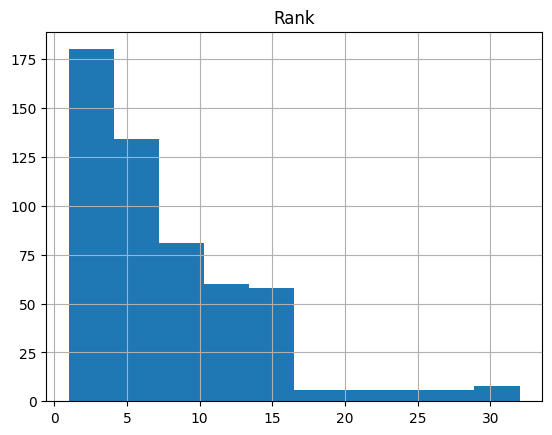

In [98]:
decks_df.hist(column="Rank")

We don't have many examples for decks ranked below 16. 

## Is there a correlation between price and rank?

<Axes: title={'center': 'Sepal Length vs Width'}, xlabel='Rank', ylabel='DeckPrices'>

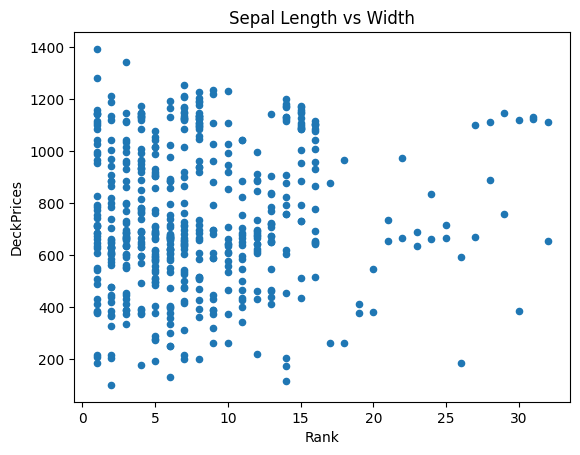

In [99]:
decks_df.plot.scatter(x='Rank', y='DeckPrices', title='Sepal Length vs Width')

# Future Work

Interested in getting the full deck list for each player and getting some card information from MTGJSON to do deeper analysis. 

In [101]:
!jupyter nbconvert --to html /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Milestone1.ipynb

[NbConvertApp] Converting notebook /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Milestone1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 2386625 bytes to /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Milestone1.html
